In [9]:
# ==========================================
# EcoSort AI - Waste Classification Retraining
# Cell 1: Import Required Libraries
# ==========================================

import os
import random
import shutil
import warnings

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import (
    Model,
    Sequential
)

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

warnings.filterwarnings("ignore")

print("=" * 50)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("=" * 50)

TensorFlow Version : 2.21.0
NumPy Version      : 2.5.1


In [10]:
# ==========================================
# Cell 2: Project Paths
# ==========================================

import os

# Notebook Folder
NOTEBOOK_DIR = os.getcwd()

# Project Root (one folder above notebooks)
PROJECT_DIR = os.path.dirname(NOTEBOOK_DIR)

# Dataset
DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "garbage-classification-v2",
    "standardized_256"
)

# Output folders
TRAIN_DIR = os.path.join(PROJECT_DIR, "dataset", "train")
VALIDATION_DIR = os.path.join(PROJECT_DIR, "dataset", "validation")
TEST_DIR = os.path.join(PROJECT_DIR, "dataset", "test")

# Save model with a NEW name
MODEL_SAVE_PATH = os.path.join(
    PROJECT_DIR,
    "backend",
    "models",
    "waste_classifier_v2.keras"
)

print("=" * 60)
print("Project Directory:")
print(PROJECT_DIR)

print("\nDataset Directory:")
print(DATASET_DIR)

print("\nTrain Directory:")
print(TRAIN_DIR)

print("\nValidation Directory:")
print(VALIDATION_DIR)

print("\nTest Directory:")
print(TEST_DIR)

print("\nModel Path:")
print(MODEL_SAVE_PATH)
print("=" * 60)

Project Directory:
d:\PROJECTS\DecodeLab\Projects\EcoSortAI

Dataset Directory:
d:\PROJECTS\DecodeLab\Projects\EcoSortAI\dataset\garbage-classification-v2\standardized_256

Train Directory:
d:\PROJECTS\DecodeLab\Projects\EcoSortAI\dataset\train

Validation Directory:
d:\PROJECTS\DecodeLab\Projects\EcoSortAI\dataset\validation

Test Directory:
d:\PROJECTS\DecodeLab\Projects\EcoSortAI\dataset\test

Model Path:
d:\PROJECTS\DecodeLab\Projects\EcoSortAI\backend\models\waste_classifier_v2.keras


In [11]:
# ==========================================
# Cell 3: Create Train / Validation / Test
# ==========================================

CLASSES = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic"
]

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

# Remove old folders if they already exist
for folder in [TRAIN_DIR, VALIDATION_DIR, TEST_DIR]:
    if os.path.exists(folder):
        shutil.rmtree(folder)

# Create new folders
for folder in [TRAIN_DIR, VALIDATION_DIR, TEST_DIR]:
    os.makedirs(folder)

for class_name in CLASSES:

    source = os.path.join(DATASET_DIR, class_name)

    train_path = os.path.join(TRAIN_DIR, class_name)
    validation_path = os.path.join(VALIDATION_DIR, class_name)
    test_path = os.path.join(TEST_DIR, class_name)

    os.makedirs(train_path)
    os.makedirs(validation_path)
    os.makedirs(test_path)

    images = os.listdir(source)

    random.shuffle(images)

    total = len(images)

    train_count = int(total * TRAIN_RATIO)
    validation_count = int(total * VALIDATION_RATIO)

    train_images = images[:train_count]

    validation_images = images[
        train_count:
        train_count + validation_count
    ]

    test_images = images[
        train_count + validation_count:
    ]

    for image in train_images:
        shutil.copy(
            os.path.join(source, image),
            os.path.join(train_path, image)
        )

    for image in validation_images:
        shutil.copy(
            os.path.join(source, image),
            os.path.join(validation_path, image)
        )

    for image in test_images:
        shutil.copy(
            os.path.join(source, image),
            os.path.join(test_path, image)
        )

    print(
        f"{class_name:<12}"
        f" Train={len(train_images):4}"
        f" Validation={len(validation_images):4}"
        f" Test={len(test_images):4}"
    )

print("\nDataset preparation completed.")

cardboard    Train= 987 Validation= 211 Test= 213
glass        Train=1215 Validation= 260 Test= 261
metal        Train= 651 Validation= 139 Test= 140
paper        Train= 935 Validation= 200 Test= 201
plastic      Train=1117 Validation= 239 Test= 241

Dataset preparation completed.


In [12]:
# ==========================================
# Cell 4: Data Generators
# ==========================================

IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.15,

    horizontal_flip=True,

    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True
)

validation_generator = validation_datagen.flow_from_directory(
    VALIDATION_DIR,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False
)

print("\nClasses:")

print(train_generator.class_indices)

Found 4905 images belonging to 5 classes.
Found 1049 images belonging to 5 classes.
Found 1056 images belonging to 5 classes.

Classes:
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4}


In [13]:
# ==========================================
# Cell 5: Build MobileNetV2 Model
# ==========================================

base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model initially
base_model.trainable = False

model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dense(
        256,
        activation="relu"
    ),

    Dropout(0.4),

    Dense(
        train_generator.num_classes,
        activation="softmax"
    )
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,592,325 (9.89 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [14]:
# ==========================================
# Cell 6: Compile Model
# ==========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [15]:
# ==========================================
# Cell 7: Training Callbacks
# ==========================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

callbacks = [
    early_stopping,
    reduce_lr,
    checkpoint
]

print("Callbacks created successfully!")

Callbacks created successfully!


In [16]:
# ==========================================
# Cell 8: Phase 1 Training
# ==========================================

INITIAL_EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=INITIAL_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5725 - loss: 1.1569
Epoch 1: val_accuracy improved from None to 0.78742, saving model to d:\PROJECTS\DecodeLab\Projects\EcoSortAI\backend\models\waste_classifier_v2.keras

Epoch 1: finished saving model to d:\PROJECTS\DecodeLab\Projects\EcoSortAI\backend\models\waste_classifier_v2.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 391s 2s/step - accuracy: 0.5725 - loss: 1.1569 - val_accuracy: 0.7874 - val_loss: 0.5962 - learning_rate: 1.0000e-04
Epoch 2/15
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7472 - loss: 0.6961
Epoch 2: val_accuracy improved from 0.78742 to 0.83889, saving model to d:\PROJECTS\DecodeLab\Projects\EcoSortAI\backend\models\waste_classifier_v2.keras

Epoch 2: finished saving model to d:\PROJECTS\DecodeLab\Projects\EcoSortAI\backend\models\waste_classifier_v2.keras
154/154 ━━━━━━━━━━━━━━━━━━━━ 254s 2s/step - accuracy: 0.7472 - loss: 0.6961 - val_accuracy: 0.8389 - val_loss: 0.4725 - learning_rate: 1.0000e-04

In [17]:
# ==========================================
# Cell 9: Fine-Tuning
# ==========================================

# Unfreeze the last 30 layers
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model...")

FINE_TUNE_EPOCHS = 10

history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Fine-tuning model...
Epoch 1/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8232 - loss: 0.4824
Epoch 1: val_accuracy did not improve from 0.88370
154/154 ━━━━━━━━━━━━━━━━━━━━ 302s 2s/step - accuracy: 0.8232 - loss: 0.4824 - val_accuracy: 0.8723 - val_loss: 0.3815 - learning_rate: 1.0000e-05
Epoch 2/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8471 - loss: 0.4088
Epoch 2: val_accuracy did not improve from 0.88370
154/154 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.8471 - loss: 0.4088 - val_accuracy: 0.8704 - val_loss: 0.3781 - learning_rate: 1.0000e-05
Epoch 3/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8595 - loss: 0.3807
Epoch 3: val_accuracy did not improve from 0.88370
154/154 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.8595 - loss: 0.3807 - val_accuracy: 0.8713 - val_loss: 0.3807 - learning_rate: 1.0000e-05
Epoch 4/10
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8734 - loss: 0.3517
Epoch 4: val_accuracy did not improve from 0.883

In [18]:
# ==========================================
# Cell 10: Evaluate on Test Dataset
# ==========================================

test_loss, test_accuracy = model.evaluate(
    test_generator,
    verbose=1
)

print("\n" + "=" * 50)
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")
print("=" * 50)

33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.8996 - loss: 0.2753

Test Accuracy : 89.96%
Test Loss     : 0.2753


In [19]:
# ==========================================
# Cell 11: Classification Report
# ==========================================

import numpy as np
from sklearn.metrics import classification_report

predictions = model.predict(test_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

33/33 ━━━━━━━━━━━━━━━━━━━━ 24s 656ms/step
              precision    recall  f1-score   support

   cardboard       0.93      0.93      0.93       213
       glass       0.88      0.91      0.90       261
       metal       0.87      0.86      0.87       140
       paper       0.92      0.89      0.91       201
     plastic       0.89      0.89      0.89       241

    accuracy                           0.90      1056
   macro avg       0.90      0.90      0.90      1056
weighted avg       0.90      0.90      0.90      1056



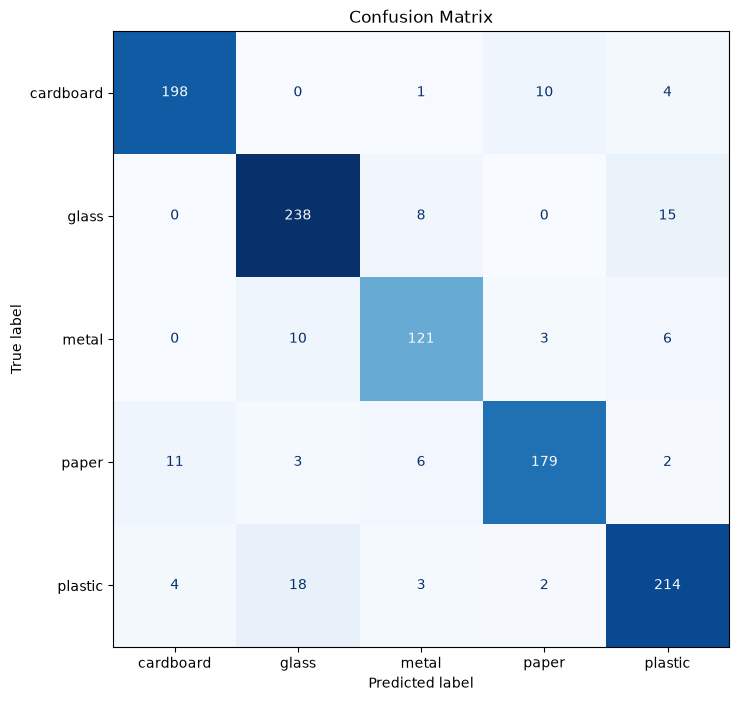

In [20]:
# ==========================================
# Cell 12: Confusion Matrix
# ==========================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()